[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/sec-filing-text-nlp-python.ipynb)

# SEC EDGAR Filing Text Extraction for NLP with Python -- Free, No API Key

Use **edgartools** to extract clean text from SEC filings for NLP and AI analysis -- completely free, no API key or paid subscription required. Get full filing text, individual sections, or structured chunks ready for machine learning pipelines and LLM context windows.

**What you'll learn:**
- Extract full filing text as plain text, markdown, or HTML
- Pull specific sections (business, risk factors, MD&A) by item number
- Get word and character counts for each section
- Search within filings for specific terms
- Access structured chunks for LLM context windows
- Compare text volumes across companies

## Install edgartools

In [1]:
!pip install -U edgartools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 18.0 MB/s eta 0:00:00


## Setup

The SEC requires all automated tools to identify themselves. Replace the email below with your own -- any valid email works.

In [2]:
import pandas as pd
from edgar import *

# The SEC requires you to identify yourself (any email works)
set_identity("your.name@example.com")

## Extract Filing Text in 3 Lines

Every SEC filing can be converted to plain text, markdown, or HTML. edgartools handles all the parsing automatically:

In [3]:
filing = Company("NVDA").get_filings(form="10-K")[0]

text = filing.text()
markdown = filing.markdown()
html = filing.html()

print(f"Plain text: {len(text):>10,} chars  ({len(text.split()):,} words)")
print(f"Markdown:   {len(markdown):>10,} chars")
print(f"HTML:       {len(html):>10,} chars")
print(f"\nFirst 500 chars of text:\n")
print(text[:500])

Plain text:    410,537 chars  (49,112 words)
Markdown:      429,312 chars
HTML:        1,967,816 chars

First 500 chars of text:

Table of Contents

UNITED STATES

SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

____________________________________________________________________________________________

FORM 10-K

  ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934  
 ────────────────────────────────────────────────────────────────────────────────────────

For the fiscal year ended January 25, 2026

OR

  TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXC


## Extract Specific Sections by Item Number

For NLP, you often need specific sections rather than the full filing. Parse a 10-K and access any section by item number:

In [4]:
tenk = filing.obj()

# Key sections for NLP analysis
business = tenk["1"]        # Item 1: Business description
risks = tenk["1A"]          # Item 1A: Risk factors
mda = tenk["7"]             # Item 7: Management Discussion & Analysis

print(f"{'Section':<20s} {'Words':>10s} {'Characters':>12s}")
print(f"{'-'*20} {'-'*10} {'-'*12}")
for name, text in [("Business", business), ("Risk Factors", risks), ("MD&A", mda)]:
    print(f"{name:<20s} {len(text.split()):>10,} {len(text):>12,}")

print(f"\nBusiness description (first 500 chars):\n")
print(business[:500])

Section                   Words   Characters
-------------------- ---------- ------------
Business                  7,028       48,222
Risk Factors             17,065      114,773
MD&A                      5,108       34,156

Business description (first 500 chars):

Item 1. Business

Our Company

NVIDIA pioneered accelerated computing to help solve the most challenging computational problems. NVIDIA is now a data center scale AI infrastructure company reshaping all industries.

Our technology stack includes the foundational NVIDIA CUDA development platform that runs on all NVIDIA GPUs, as well as hundreds of domain-specific software libraries, frameworks, algorithms, software development kits, or SDKs, and application programming interfaces, or APIs. This d


In [22]:
# 2. Lista de empresas tecnológicas
import re

def natural_sort_key(item):
    """
    Generates a key for natural sorting of item strings like 'Item 1', 'Item 1A'.
    It splits the string into a list of number and non-number chunks.
    """
    # Split the string into numbers and non-numbers
    # e.g., 'Item 1A' -> ['Item ', 1, 'A']
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('([0-9]+)', item)]

tech_tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN", "META"]

for i in tech_tickers:
    print('*'*40)
    print(i)
    filing = Company(i).get_filings(form="10-K")[0]
    tenk = filing.obj()
    #print(sorted(tenk.items, key=natural_sort_key))
    #print(type(tenk.items))
    #for item in tenk.items:
    for item in sorted(tenk.items, key=natural_sort_key):
      text = tenk[item]
      words = len(text.split())
      print(f"{item:12s} {words:>8,} words  {len(text):>8,} chars")



****************************************
AAPL
Item 1          2,325 words    16,054 chars
Item 1A         9,782 words    68,163 chars
Item 1B             6 words        44 chars
Item 1C           370 words     2,705 chars
Item 2             83 words       521 chars
Item 3            830 words     5,409 chars
Item 4            440 words     2,979 chars
Item 5            404 words     2,648 chars
Item 6             11 words        55 chars
Item 7          2,643 words    18,018 chars
Item 7A           451 words     3,034 chars
Item 8          8,491 words    60,874 chars
Item 9             14 words       102 chars
Item 9A           649 words     4,513 chars
Item 9B            83 words       575 chars
Item 9C           352 words     2,581 chars
Item 10            60 words       401 chars
Item 11           284 words     2,080 chars
Item 12            34 words       232 chars
Item 13            30 words       211 chars
Item 14            37 words       219 chars
Item 15         1,761 words   

### Comparing Word Counts for Key 10-K Items Across Companies

To visualize the comparative disclosure for important sections, we'll collect the word counts for 'Item 1' (Business), 'Item 1A' (Risk Factors), and 'Item 7' (Management's Discussion & Analysis) for each of the `tech_tickers`.

In [25]:
import pandas as pd
from IPython.display import display

# Initialize a list to store data for plotting
plot_data = []

# Define the key items we want to compare
key_items_to_plot = ['Item 1', 'Item 1A', 'Item 7']

# Loop through each technology ticker
for ticker_symbol in tech_tickers:
    print(f"Processing {ticker_symbol}...")
    try:
        # Get the latest 10-K filing for the company
        filing = Company(ticker_symbol).get_filings(form="10-K")[0]
        tenk = filing.obj()

        # Prepare a dictionary to hold the word counts for this ticker
        ticker_item_counts = {'Ticker': ticker_symbol}

        # Collect word counts for the key items
        for item_name in key_items_to_plot:
            if item_name in tenk.items:
                text = tenk[item_name]
                words = len(text.split())
                ticker_item_counts[item_name] = words
            else:
                # Handle cases where an item might not be present (e.g., if a 10-K structure differs)
                ticker_item_counts[item_name] = 0 # Or numpy.nan if you prefer

        plot_data.append(ticker_item_counts)

    except Exception as e:
        print(f"Could not process {ticker_symbol}: {e}")

# Convert the collected data into a pandas DataFrame
df_item_comparison = pd.DataFrame(plot_data)

display(df_item_comparison)

Processing AAPL...
Processing MSFT...
Processing NVDA...
Processing GOOGL...
Processing AMZN...
Processing META...


,Ticker,Item 1,Item 1A,Item 7
0,AAPL,2325,9782,2643
1,MSFT,6806,10020,7131
2,NVDA,7028,17065,5108
3,GOOGL,3551,12591,7703
4,AMZN,1904,8773,6722
5,META,3714,29846,9019


### Visualizing Word Counts by Key Item and Ticker

This grouped bar chart visually compares the word counts of 'Item 1' (Business), 'Item 1A' (Risk Factors), and 'Item 7' (MD&A) across the selected tech companies. It helps in understanding which companies provide more detailed disclosures in these critical sections.

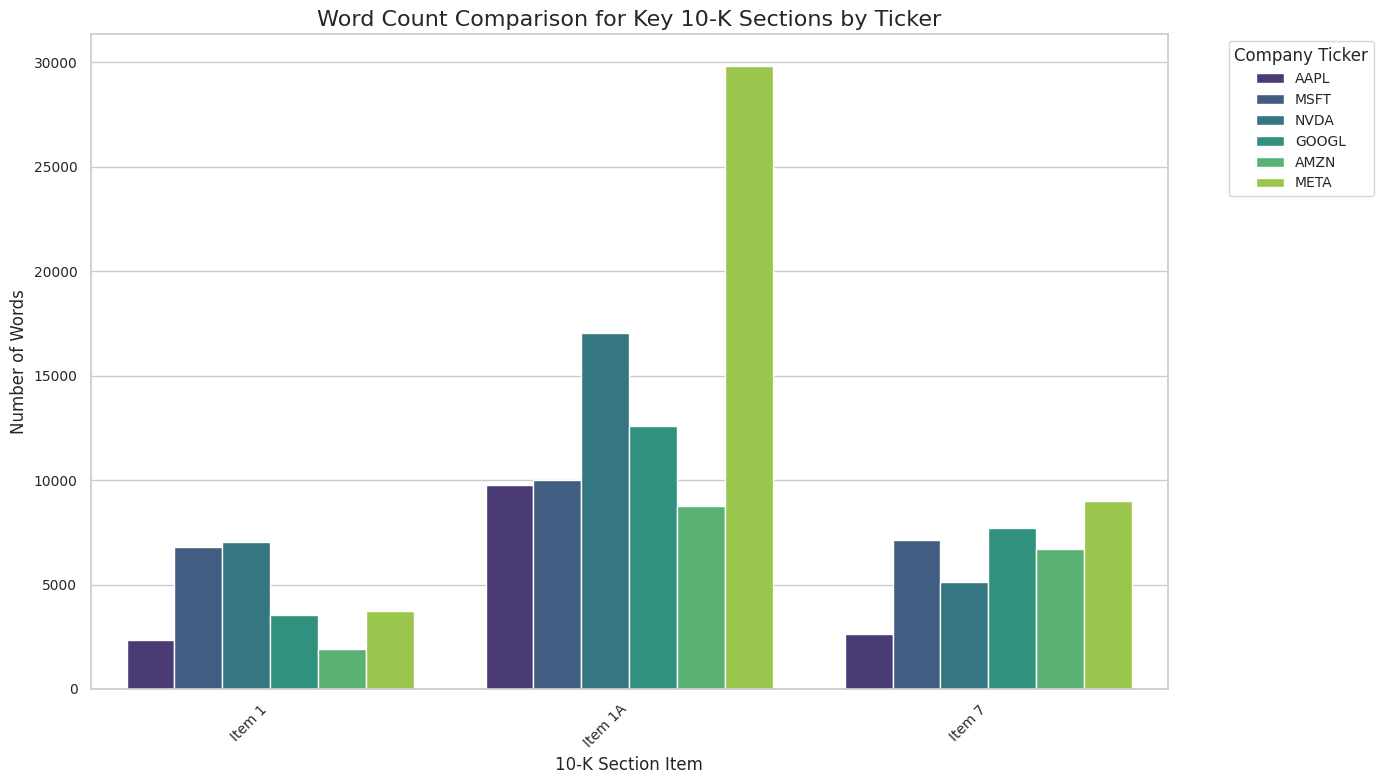

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted_plot = df_item_comparison.melt(
    id_vars=['Ticker'],
    value_vars=key_items_to_plot,
    var_name='Section Item',
    value_name='Word Count'
)

# Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Create the grouped bar plot
sns.barplot(data=df_melted_plot, x='Section Item', y='Word Count', hue='Ticker', palette='viridis')

plt.title('Word Count Comparison for Key 10-K Sections by Ticker', fontsize=16)
plt.xlabel('10-K Section Item', fontsize=12)
plt.ylabel('Number of Words', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Company Ticker', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

To sort items like 'Item 1', 'Item 1A', 'Item 2', and 'Item 10' correctly (i.e., 'Item 1', 'Item 1A', 'Item 2', ..., 'Item 10'), a simple alphabetical sort isn't sufficient. Python's default `sort()` or `sorted()` would place 'Item 10' before 'Item 2' because it compares character by character. We need a custom sorting key that can extract the numerical part of the item and sort based on that, while also handling any trailing letters (like 'A' in 'Item 1A').

## All Available Sections

A 10-K has over 20 sections. See what's available and how much text each contains:

In [5]:
for item in tenk.items:
    text = tenk[item]
    words = len(text.split())
    print(f"{item:12s} {words:>8,} words  {len(text):>8,} chars")

Item 1          7,028 words    48,222 chars
Item 1A        17,065 words   114,773 chars
Item 1B             6 words        41 chars
Item 16           391 words     4,022 chars
Item 1C           551 words     3,957 chars
Item 2            143 words       925 chars
Item 3             35 words       197 chars
Item 4              9 words        57 chars
Item 5            813 words     5,220 chars
Item 6              3 words        18 chars
Item 7          5,108 words    34,156 chars
Item 7A           657 words     4,247 chars
Item 8             32 words       207 chars
Item 9             14 words        99 chars
Item 9A           506 words     3,417 chars
Item 9B           104 words       729 chars
Item 9C            66 words       429 chars
Item 10           388 words     2,560 chars
Item 11            44 words       360 chars
Item 12            88 words       640 chars
Item 13            64 words       455 chars
Item 14            45 words       304 chars
Item 15        15,085 words   10

## Search Within a Filing

Search for specific terms or topics within a filing to find relevant passages:

In [6]:
results = filing.search("artificial intelligence")
print(f"Found {len(results)} matching sections")
results

Found 2 matching sections


                                      Searching for 'artificial intelligence'                                      
  ╭──────────────────────────────────────────────────── 26 ─────────────────────────────────────────────────────╮  
  │ Item 1. Business Our Company NVIDIA pioneered accelerated computing to help solve the most challenging      │  
  │ computational problems. NVIDIA is now a data center scale AI infrastructure company reshaping all           │  
  │ industries. Our technology stack includes the foundational NVIDIA CUDA development platform that runs on    │  
  │ all NVIDIA GPUs, as well as hundreds of domain-specific software libraries, frameworks, algorithms,         │  
  │ software development kits, or SDKs, and application programming interfaces, or APIs. This deep and broad    │  
  │ software stack accelerates the performance and facilitates the deployment of NVIDIA accelerated computing   │  
  │ for computationally intensive workloads such as artificial intellige

## Structured Chunks for LLM Context

The chunked document breaks a filing into labeled segments, ideal for RAG pipelines or fitting within LLM context windows:

In [7]:
chunked = tenk.chunked_document
df = chunked.as_dataframe()

print(f"Total chunks: {len(df)}")
print(f"Columns: {df.columns.tolist()}\n")

# Chunks per section
sections = df[df["Item"] != ""].groupby("Item").agg(
    Chunks=("Chars", "count"),
    Total_Chars=("Chars", "sum")
).sort_values("Total_Chars", ascending=False)

sections.head(10)

Total chunks: 336
Columns: ['Text', 'Table', 'Chars', 'Signature', 'TocLink', 'Toc', 'Empty', 'Part', 'Item']



,Chunks,Total_Chars
Item,,
Item 15,197,160143
Item 1A,17,114427
Item 1,14,48199
Item 7,38,37713
Item 5,8,6742
Item 7A,2,4233
Item 1C,3,3946
Item 9A,2,3405
Item 10,1,2546


## Compare Text Volumes Across Companies

Different companies disclose varying levels of detail. Compare text volumes to understand disclosure depth:

In [8]:
tickers = ["NVDA", "MSFT", "AAPL", "GOOG"]
rows = []

for ticker in tickers:
    filing = Company(ticker).get_filings(form="10-K")[0]
    tenk = filing.obj()
    text = filing.text()
    rows.append({
        "Ticker": ticker,
        "Total Words": f"{len(text.split()):,}",
        "Business": f"{len(tenk['1'].split()):,}",
        "Risk Factors": f"{len(tenk['1A'].split()):,}",
        "MD&A": f"{len(tenk['7'].split()):,}",
    })

pd.DataFrame(rows).set_index("Ticker")

,Total Words,Business,Risk Factors,MD&A
Ticker,,,,
NVDA,"49,112","7,028","17,065","5,108"
MSFT,"45,954","6,806","10,020","7,131"
AAPL,"29,354","2,325","9,782","2,643"
GOOG,"49,582","3,551","12,591","7,703"


## Why EdgarTools?

EdgarTools is free and open-source. Compare extracting SEC filing text:

**With edgartools (free, no API key):**
```python
filing = Company("NVDA").get_filings(form="10-K")[0]
text = filing.text()            # Full text
tenk = filing.obj()
tenk["1A"]                      # Risk factors section
filing.search("AI")             # Search within filing
```

**Typical paid API approach ($50+/month, API key required):**
```python
from sec_api import ExtractorApi
api = ExtractorApi(api_key="YOUR_PAID_API_KEY")
text = api.get_section(url, "1A", "text")  # One section per API call
# ... rate-limited, paid per request, no search capability
```

With edgartools, the entire filing is parsed locally -- all sections, search, and chunks available instantly with no per-request cost.

## Quick Reference

```python
from edgar import *
set_identity("your.name@example.com")

# ── Full filing text ──
filing = Company("NVDA").get_filings(form="10-K")[0]
filing.text()                          # Plain text
filing.markdown()                      # Markdown
filing.html()                          # HTML

# ── Sections by item number ──
tenk = filing.obj()
tenk["1"]                              # Business description
tenk["1A"]                             # Risk factors
tenk["7"]                              # MD&A
tenk.items                             # List all items

# ── Search ──
filing.search("artificial intelligence")  # Find matching passages

# ── Structured chunks ──
chunked = tenk.chunked_document
df = chunked.as_dataframe()            # All chunks with metadata
# Columns: Text, Table, Chars, Part, Item
```

## What's Next

You've learned how to extract SEC filing text for NLP analysis. Here are related tutorials:

- [Analyze 10-K Annual Reports](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/analyze-10k-annual-report-python.ipynb)
- [Download SEC Filings in Bulk](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/download-sec-filings-bulk-python.ipynb)
- [Search and Filter SEC Filings](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/search-sec-filings-python.ipynb)
- [SEC EDGAR API in Python](https://colab.research.google.com/github/dgunning/edgartools/blob/main/notebooks/sec-edgar-api-python.ipynb)

**Resources:**
- [EdgarTools Documentation](https://edgartools.readthedocs.io/)
- [GitHub Repository](https://github.com/dgunning/edgartools)
- [PyPI Package](https://pypi.org/project/edgartools/)

---

## Support EdgarTools

If you found this tutorial helpful, here are a few ways to support the project:

- **Star the repo** -- [github.com/dgunning/edgartools](https://github.com/dgunning/edgartools) -- it helps others discover edgartools
- **Visit edgartools.io** -- [edgartools.io](https://www.edgartools.io/) -- for more tutorials, articles, and updates
- **Report issues** -- found a bug or have a feature idea? [Open an issue](https://github.com/dgunning/edgartools/issues)
- **Share this notebook** -- know someone who works with SEC data? Send them the Colab link

*edgartools is free, open-source, and community-driven. No API key or paid subscription required.*